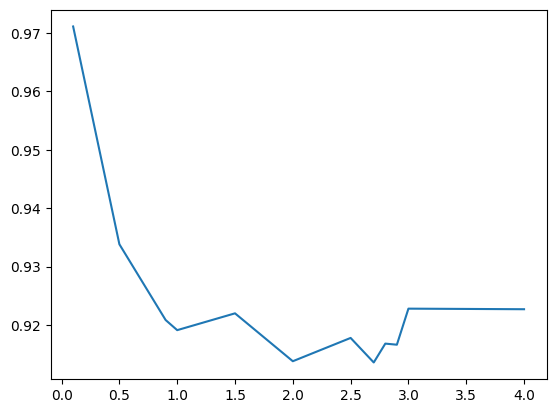

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

def make_rwmh(log_tgt_density, log_proposal_density, proposal_sampler):
  def log_acceptance_ratio(x, y):
    return np.min([log_tgt_density(y) + log_proposal_density(y, x) - log_tgt_density(x) - log_proposal_density(x, y), 0])

  def rwmh(key, x0, n_samples, n_burnin):
    np.random.seed(key)
    my_chain = np.zeros((n_samples, *x0.shape))
    for i in range(1, n_samples):
      current_state = my_chain[i-1]
      proposed_state = proposal_sampler(current_state)
      r = log_acceptance_ratio(current_state, proposed_state)
      u = np.log(np.random.rand())
      if u < r:
        # We accept the proposed state
        my_chain[i] = proposed_state
      else:
        my_chain[i] = current_state
    return my_chain[n_burnin:]

  return rwmh

rho = 0.9
log_tgt_density = lambda x: stats.multivariate_normal.logpdf(x, mean=np.zeros(2), cov=np.array([[1, rho], [rho, 1]]))
def make_proposal(tau):
  cov_proposal = tau * np.eye(2)
  def log_proposal_density(x, y):
    return stats.multivariate_normal.logpdf(y, mean=x, cov=cov_proposal)
  def proposal_sampler(x):
    return stats.multivariate_normal.rvs(mean=x, cov=cov_proposal)
  return log_proposal_density, proposal_sampler

def acf(chain, order):
  n = len(chain)
  mean = np.mean(chain, axis=0)
  var = np.mean((chain-mean[None,:])**2, axis=0)
  acfs = np.zeros((order + 1, 2))
  acfs[0] = 1.0
  for o in range(1, order+1):
    acfs[o] = np.mean((chain[o:]-mean[None,:])*(chain[:n-o]-mean[None,:]), axis=0)/var
  return acfs


init = np.zeros(2)
key = 0
n_samples = 10000
taus = [0.1, 0.5, 0.9, 1, 1.5, 2., 2.5, 2.7, 2.8, 2.9, 3, 4]
my_acf_of_order1 = np.zeros(len(taus))
for idx_tau, tau in enumerate(taus):
  log_proposal_density, proposal_sampler = make_proposal(tau)
  my_rwmh = make_rwmh(log_tgt_density, log_proposal_density, proposal_sampler)
  my_chain = my_rwmh(key, init, n_samples, 1000)
  #plt.plot(my_chain)
  my_acf_of_order1[idx_tau] = acf(my_chain, 1)[1].mean()
plt.plot(taus, my_acf_of_order1)

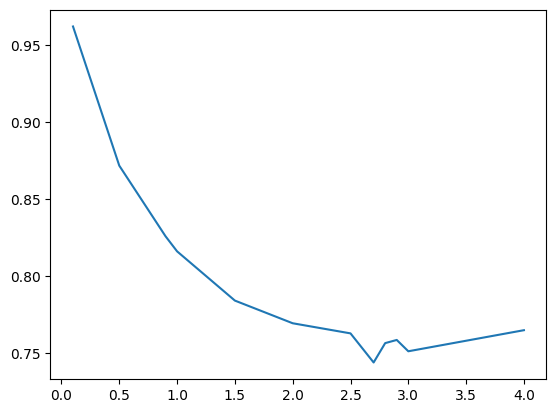

In [ ]:

def make_proposal_bis(tau):
  cov_proposal = tau * np.array([[1, rho], [rho, 1]])
  def log_proposal_density(x, y):
    return stats.multivariate_normal.logpdf(y, mean=x, cov=cov_proposal)
  def proposal_sampler(x):
    return stats.multivariate_normal.rvs(mean=x, cov=cov_proposal)
  return log_proposal_density, proposal_sampler


init = np.zeros(2)
key = 0
n_samples = 10000
taus = [0.1, 0.5, 0.9, 1, 1.5, 2., 2.5, 2.7, 2.8, 2.9, 3, 4]
my_acf_of_order1 = np.zeros(len(taus))
for idx_tau, tau in enumerate(taus):
  log_proposal_density, proposal_sampler = make_proposal_bis(tau)
  my_rwmh = make_rwmh(log_tgt_density, log_proposal_density, proposal_sampler)
  my_chain = my_rwmh(key, init, n_samples, 1000)
  #plt.plot(my_chain)
  my_acf_of_order1[idx_tau] = acf(my_chain, 1)[1].mean()
plt.plot(taus, my_acf_of_order1)
